In [1]:
import xgboost as xgb
import shap
import pandas as pd
from sklearn.model_selection import train_test_split

# Load model
df = pd.read_parquet("/data/big/fmoss/data/model_input_dataset/training_dataset_weighted_N_events.parquet")

features = [
    "wind_speed",
    # "track_distance",
    "rainfall_max_24h",
    "N_events_5_years",
    # "N_events_5_years_weighted",
    "population",
    "coast_length",
    "with_coast",
    "mean_elev",
    "mean_slope",
    "mean_rug",
    "urban",
    "rural",
    "water",
    "storm_tide_rp_0010",
    "landslide_risk_sum",
    # "flood_risk",
    # "shdi"
    ]

# Example setup
X = df[features] 
y = df["perc_affected_pop_grid_region"]

# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=0)


/home/fmoss/miniconda3/envs/env6/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


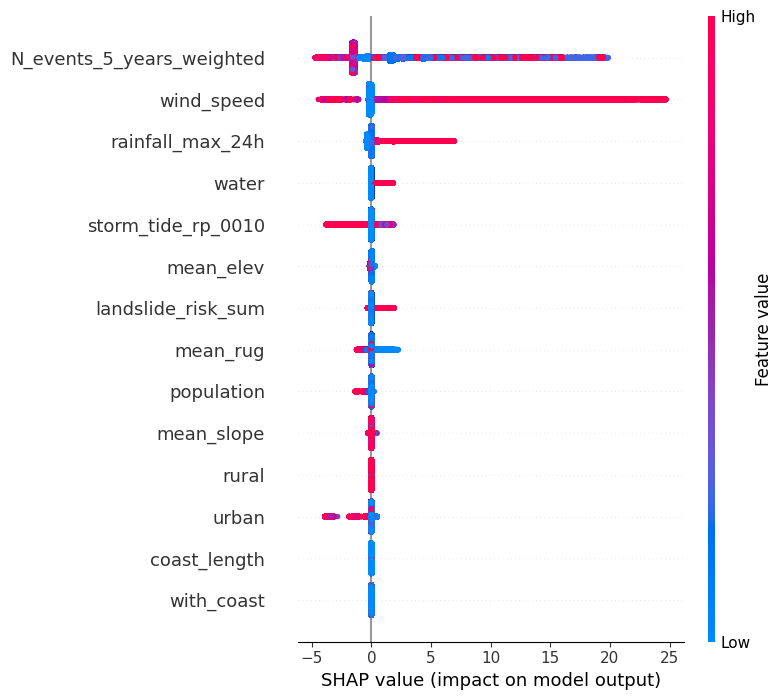

In [2]:
# Load shap values
import joblib
import shap
import matplotlib.pyplot as plt

# Load SHAP values
shap_values_stage_2 = joblib.load("/data/big/fmoss/data/model_output/shap/shap_values_stage2.pkl")

# Important: we need the dataset X that was used to compute SHAP
# e.g. if you passed df[features] originally, reload it:
X = df[features]   # <-- make sure it's the same features order as when saving

# Plot beeswarm summary
shap.summary_plot(shap_values_stage_2, X, show=False)

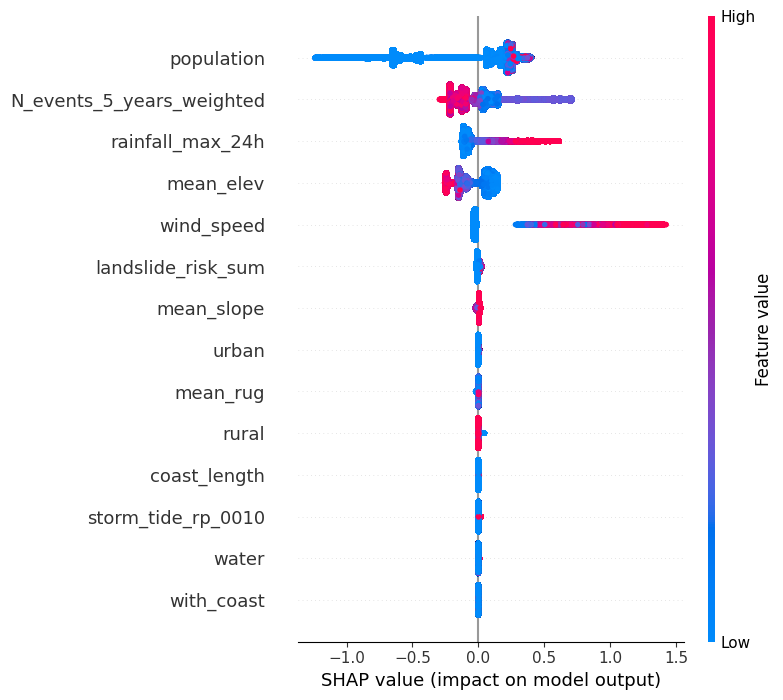

In [3]:
# Load shap values
import joblib
import shap
import matplotlib.pyplot as plt
# Load SHAP values
shap_values_stage_1 = joblib.load("/data/big/fmoss/data/model_output/shap/shap_values_stage1.pkl")

# Important: we need the dataset X that was used to compute SHAP
# e.g. if you passed df[features] originally, reload it:
X = df[features]   # <-- make sure it's the same features order as when saving

# Plot beeswarm summary
shap.summary_plot(shap_values_stage_1, X, show=False)

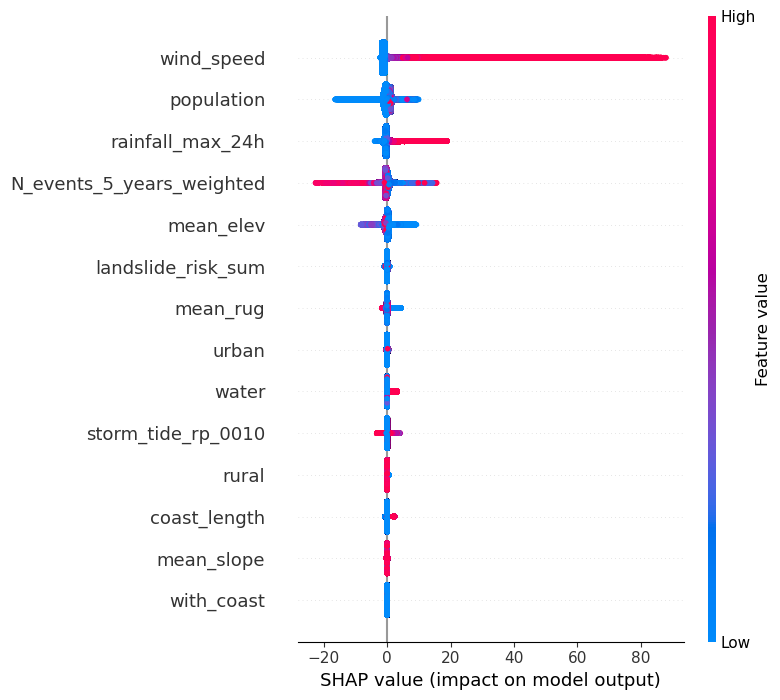

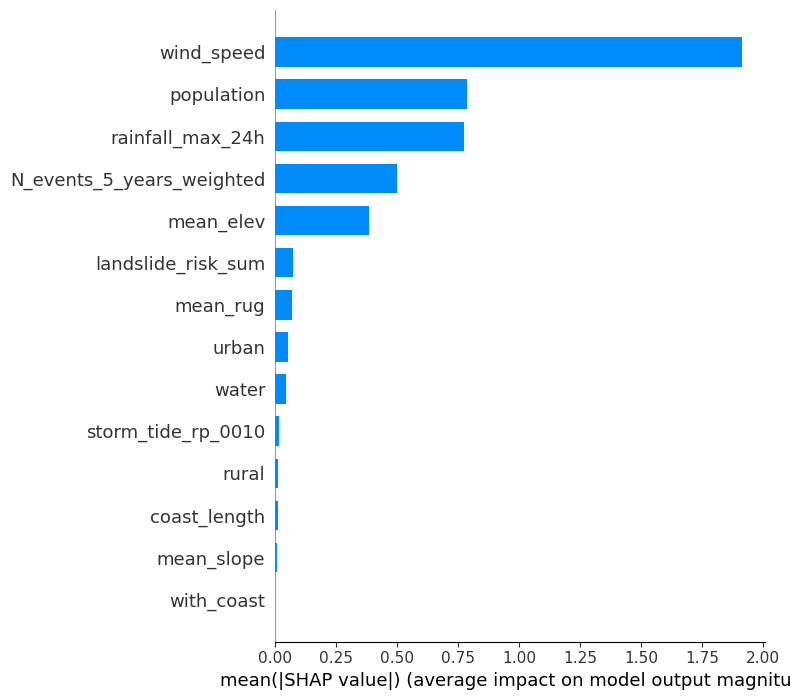

In [ ]:
from xgboost.sklearn import XGBRegressor

xgb_params = {
        "booster": "gbtree",
        "colsample_bytree": 0.8,
        "gamma": 0.5,
        "learning_rate": 0.1,
        "max_depth": 4,
        "min_child_weight": 4,
        "n_estimators": 100,
        # "early_stopping_rounds": 10,
        "objective": "reg:quantileerror",
        "quantile_alpha": 0.99,
        "subsample": 0.8,
        "verbosity": 0,
        "eval_metric": "mae",
        "random_state": 0,
    }

model = XGBRegressor(**xgb_params)
model.fit(X, y)

# Compute SHAP values
explainer = shap.Explainer(model)
shap_values = explainer(X)

# Plot feature importance
shap.summary_plot(shap_values, X)               # Beeswarm
shap.summary_plot(shap_values, X, plot_type="bar")  # Bar chart


Paper fig

In [2]:
import joblib
import shap
import matplotlib.pyplot as plt
# Load SHAP values
shap_values_stage_1 = joblib.load("/data/big/fmoss/data/model_output/shap/shap_values_stage1.pkl")
shap_values_stage_2 = joblib.load("/data/big/fmoss/data/model_output/shap/shap_values_stage2.pkl")

# Important: we need the dataset X that was used to compute SHAP
# e.g. if you passed df[features] originally, reload it:
X = df[features]   # <-- make sure it's the same features order as when saving


In [3]:
feature_rename_map = {
    "wind_speed": "WEA_wind_speed",
    # "track_distance": "WEA_track_dist",
    "rainfall_max_24h": "WEA_rainfall_max_24h",
    "N_events_5_years": "prev_events_5years",  # Updated to match Table Label 14
    # "N_events_5_years_weighted": "prev_events_5years", 
    "population": "total_pop",
    "coast_length": "TOP_coast_length",
    "with_coast": "TOP_with_coast",
    "mean_elev": "TOP_mean_elevation_m",
    "mean_slope": "TOP_mean_slope",
    "mean_rug": "TOP_mean_rug",
    "urban": "URB_urban",
    "rural": "URB_rural",
    "water": "URB_water",
    "storm_tide_rp_0010": "SH_storm_tides",      # Corrected prefix to SH (Secondary Hazards)
    "landslide_risk_sum": "SH_landslides_risk",   # Corrected prefix to SH (Secondary Hazards)
    # "flood_risk": "VUL_flood_risk",
    # "shdi": "VUL_shdi"
}

# Rename the columns of your SHAP values or training data
X_renamed = X[feature_rename_map.keys()].rename(columns=feature_rename_map)


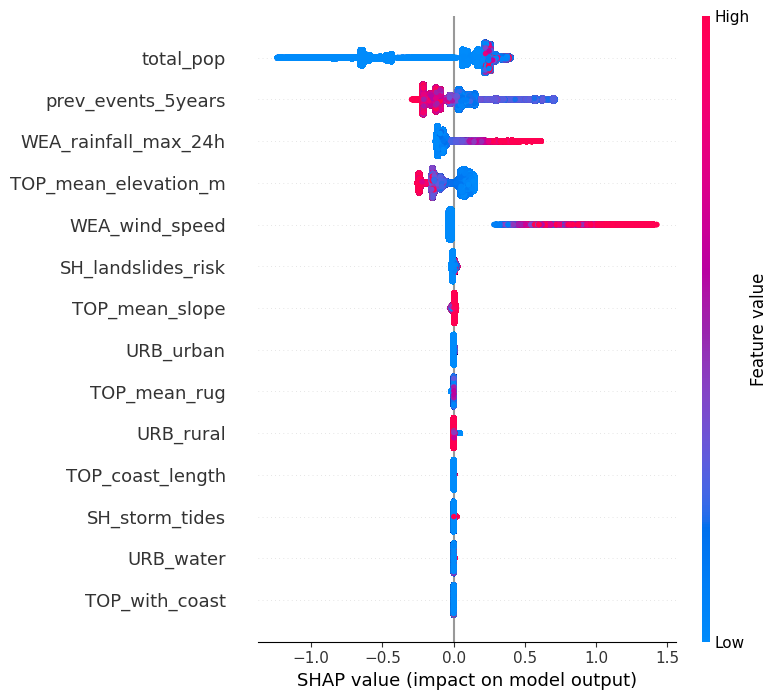

: 

In [ ]:
# Plot SHAP summary with renamed features
shap.summary_plot(shap_values_stage_1.values, features=X_renamed, feature_names=X_renamed.columns, show=False)
plt.tight_layout()
# plt.savefig("shap_summary.pdf", bbox_inches='tight')  # Save for paper
plt.show()

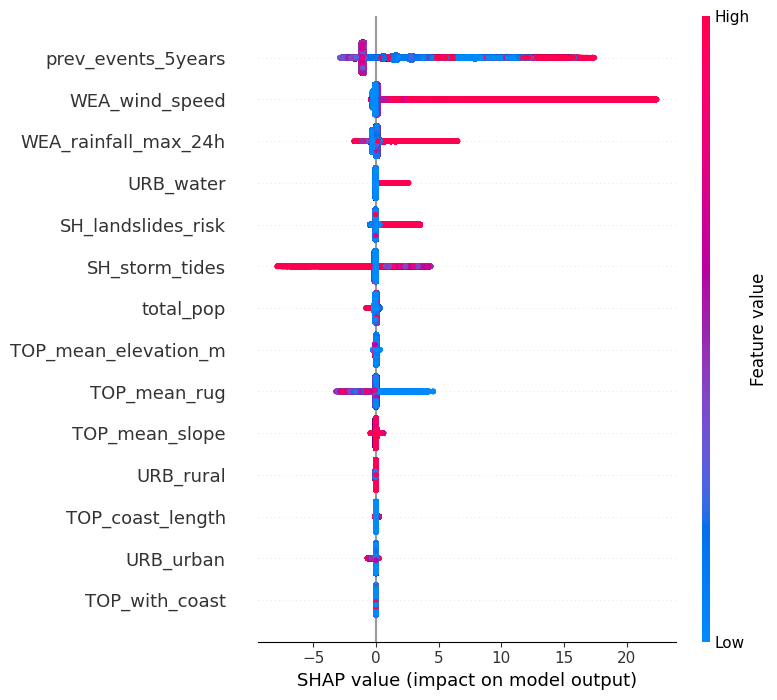

In [4]:
# Plot SHAP summary with renamed features
shap.summary_plot(shap_values_stage_2.values, features=X_renamed, feature_names=X_renamed.columns, show=False)
plt.tight_layout()
# plt.savefig("shap_summary.pdf", bbox_inches='tight')  # Save for paper
plt.show()

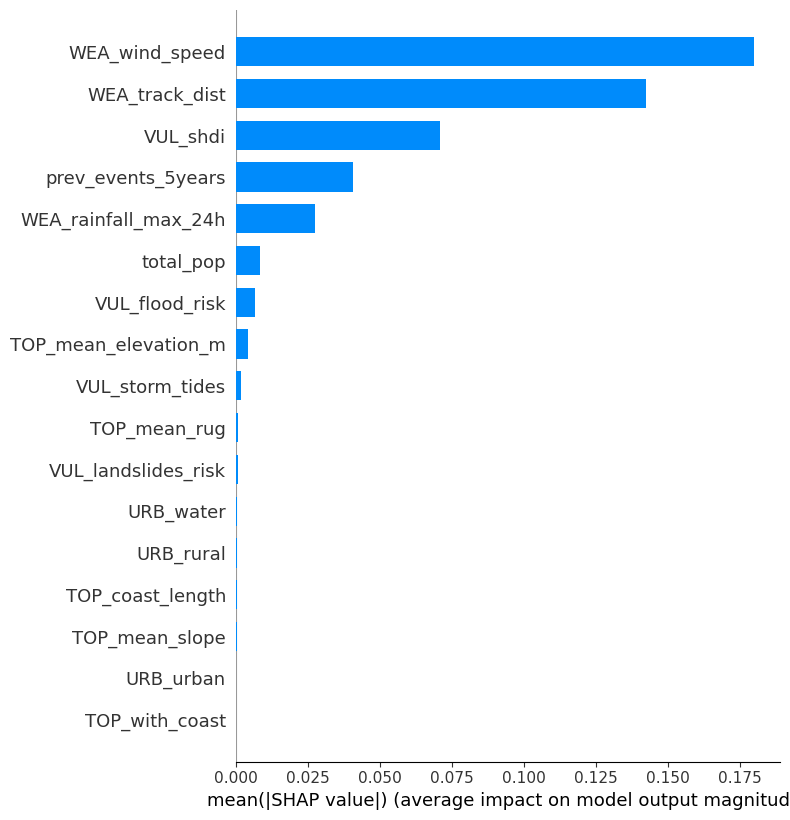

In [12]:
# Plot SHAP summary with renamed features
shap.summary_plot(shap_values.values, features=X_renamed, feature_names=X_renamed.columns, show=False, plot_type="bar")
plt.tight_layout()
# plt.savefig("shap_summary.pdf", bbox_inches='tight')  # Save for paper
plt.show()